### Prerequisites:

Before we dive into the implementation, we have to install some prerequisistes:

 - we use [pandas](https://pandas.pydata.org/docs/) to easily load and format our data
 - we use the [crepes](https://github.com/henrikbostrom/crepes) library together with [scikit-learn](https://scikit-learn.org/stable/api/index.html) to implement our conformal base classifier
 - we use Meta's open source LLM [Llama 3.2-3B](https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct) for prompting

Furthermore, we will perform our experiments on the [Yahoo Answers Topics Dataset](https://huggingface.co/datasets/community-datasets/yahoo_answers_topics).

In [1]:
%%capture
# install dependecies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers accelerate tqdm

### Data processing

In [2]:
from datasets import load_dataset

train_data = load_dataset("community-datasets/yahoo_answers_topics", split="train") 
test_data = load_dataset("community-datasets/yahoo_answers_topics", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 1400000 examples
Test set size: 60000 examples


In [3]:
# get the label names:
label_names = train_data.features['topic'].names

# rename some labels for clarity:
label_names = [name.replace("Society & Culture", "Culture") for name in label_names]
label_names = [name.replace("Science & Mathematics", "Science") for name in label_names]
label_names = [name.replace("Education & Reference", "Education") for name in label_names]
label_names = [name.replace("Computers & Internet", "Tech") for name in label_names]
label_names = [name.replace("Business & Finance", "Business") for name in label_names]
label_names = [name.replace("Entertainment & Music", "Entertainment") for name in label_names]
label_names = [name.replace("Family & Relationships", "Family") for name in label_names]
label_names = [name.replace("Politics & Government", "Politics") for name in label_names]

# create a mapping from index to label:
index2label = {i: name for i, name in enumerate(label_names)}
index2label

{0: 'Culture',
 1: 'Science',
 2: 'Health',
 3: 'Education',
 4: 'Tech',
 5: 'Sports',
 6: 'Business',
 7: 'Entertainment',
 8: 'Family',
 9: 'Politics'}

In [4]:
# convert datasets to dataframes:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

# filter all the questions_content that are empty strings:
train_df = train_df[train_df['question_content'].str.strip().astype(bool)]
test_df = test_df[test_df['question_content'].str.strip().astype(bool)]

train_df.sample()

,id,topic,question_title,question_content,best_answer
1339179,1339179,8,How do I let someone down easy?,I have a boyfriend that I would never leave fo...,A girl who once broke up with me made me a spa...


In [5]:
from sklearn.model_selection import train_test_split

# sample 5k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["topic"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["topic"], train_size=1000, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 2000 examples
Test subset size: 1000 examples


We use the `label` associated with each news `text` as the target category to predict:

In [6]:
# map numeric labels to string labels:
train_df['label'] = train_df['topic'].map(index2label)
test_df['label'] = test_df['topic'].map(index2label)

In [7]:
# select input and label from data:
X_train = train_df['question_content'].to_numpy()
y_train = train_df['label'].to_numpy()

X_test = test_df['question_content'].to_numpy()
y_test = test_df['label'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  10


### Sparse Frequency-based Embeddings for Similarity

We import TfidfVectorizer from `sklearn.feature_extraction.text` and use it to create and fit a TF-IDF input embedding on the `X_train` data. Since `TfidfVectorizer.transform(...)` returns a sparse matrix.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# create and train input embedding:
tfidf = TfidfVectorizer().fit(X_train)

# since TfidfVectorizer.transform(...) returns a sparse matrix which 'crepes'
# does not handle well, we use the following utility function to encode our texts:
phi = lambda x: tfidf.transform(x).toarray()

# print a sample of the vocabulary to show that we learned something:
list(tfidf.vocabulary_.keys())[:5]

['for', 'iran', 'have', 'had', 'depression']

Now let's create a list of unique labels (`id2label`) from the training labels `y_train`. We then build a dictionary (`label2id`) that maps each label to a unique ID using enumeration. Finally, we display the label-to-ID mapping by printing `label2id`.

In [9]:
import numpy as np

# create label to one-hot and reverse dictionaries:
id2label = np.unique(y_train)
label2id = {l:i for i, l in enumerate(id2label)}

# show label-id mapping:
label2id

{'Business': 0,
 'Culture': 1,
 'Education': 2,
 'Entertainment': 3,
 'Family': 4,
 'Health': 5,
 'Politics': 6,
 'Science': 7,
 'Sports': 8,
 'Tech': 9}

In [10]:
from sklearn.metrics import pairwise_distances

def get_fixed_k_examples(text, k=2):
    """
    Return exactly k training examples with highest cosine similarity to `text`,
    selected globally across all classes.
    Returns list of (text, label, similarity) tuples sorted by descending similarity.
    """
    embeddings = phi([text] + X_train.tolist())
    similarity = (1. - pairwise_distances(embeddings[:1], embeddings[1:], metric="cosine"))[0]
    top_k_idx = np.argsort(similarity)[::-1][:k]
    return [(X_train[i], y_train[i], similarity[i]) for i in top_k_idx]

In [11]:
# verify: show the 1 globally most similar training examples to the first test sample:
n = 1
t = X_test[0]
examples = get_fixed_k_examples(t, k=n)
print(f"Query: {t!r}\n")
for i, (text, label, sim) in enumerate(examples):
    print(f"{i+1}. [{label}] (sim={sim:.3f}) {text!r}")

Query: "Hitler censored Eric Maria Remarque's All Quiet on the western front. Which details in the novel would cause Hitler to take such action? Considering Hitler's goals, was he justified in censoring the novel?"

1. [Education] (sim=0.171) 'I have a novel kicking around in my head. Very fresh idea but, need an experienced writer to make it come to life.'


### Instantiate Llama

In order to be able to use huggingface's Llama 3.2 models, we first need to log in to huggingface (you can request access to the model [here](https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct)).

In [12]:
# import getpass
# from huggingface_hub import login
# login(getpass.getpass('Enter your huggingface API-key:'))

In this tutorial we will use the standard huggingface text-generation pipeline (compressed to 16 bit floating point weights) for the instruction tuned 3B parameter version of Llama 3.2.

In [13]:
import transformers
import torch

# create llm pipeline:
llm = transformers.pipeline(
    "text-generation",
    model="meta-llama/Llama-3.2-3B-Instruct",
    dtype=torch.bfloat16,
    device_map="auto"
)
llm.model.generation_config.max_length = None

# Get special tokens for later:
bos_token_id = llm.tokenizer.convert_tokens_to_ids('<|begin_of_text|>')
eos_token_id = llm.tokenizer.convert_tokens_to_ids('<|eot_id|>')
pad_token_id = llm.tokenizer.convert_tokens_to_ids('<|eot_id|>')

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

### Results Handling Helper

In [14]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json

def save_results(y_true, y_pred, classes, filename="results.json"):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        classes: List of all class labels (keeps consistent ordering)
        filename: Output JSON filename
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes 
    }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [15]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file, 
    including summary statistics.

    Args:
        prompt_lengths: List of total prompt token counts.
        input_lengths: List of input (test text) token counts.
        shots_lengths: List of few-shot section token counts.
        num_shots: List of number of few-shot examples per prompt.
        filename: Output JSON filename.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### Few-shot learning with Most Similar Examples (Sparse Embeddings)

Generate a prompt for classification using a given text and $n$ labeled examples.

In [16]:
def get_prompt(text, shots):
    replace_qm = lambda s: s.replace('"', "'")
    prompt = 'We classify user questions into topic categories based on their text. Here are some labelled examples:\n'
    for x,y in shots: prompt += f'\n"{replace_qm(x)}" => {y}'
    return {"role": "user", "content": f'{prompt}\n\nPlease predict the correct class for the following sample. Only provide the class label.\n\n"{replace_qm(text)}" => '}

shots_examples = get_fixed_k_examples(X_test[0], k=n)
shots = [(x, y) for x, y, _ in shots_examples]
prompt = get_prompt(X_test[0], shots)["content"]
print(prompt)

We classify user questions into topic categories based on their text. Here are some labelled examples:

"I have a novel kicking around in my head. Very fresh idea but, need an experienced writer to make it come to life." => Education

Please predict the correct class for the following sample. Only provide the class label.

"Hitler censored Eric Maria Remarque's All Quiet on the western front. Which details in the novel would cause Hitler to take such action? Considering Hitler's goals, was he justified in censoring the novel?" => 


In [17]:
from tqdm import tqdm
import numpy as np

def few_shot_learning_batch(test, y_train, n=2):
    outputs        = []
    prompt_lengths = []
    input_lengths  = []
    shots_lengths  = []
    num_shots      = []

    for i, t in tqdm(enumerate(test), total=len(test)):
        shots_examples = get_fixed_k_examples(t, k=n)
        shots = [(x, y) for x, y, _ in shots_examples]
        num_shots.append(len(shots))
        prompt = get_prompt(t, shots)
        prompt_len  = len(llm.tokenizer(prompt["content"])["input_ids"])
        input_len   = len(llm.tokenizer(t)["input_ids"])
        shots_text  = "\n".join([x for x, _ in shots])
        shots_len   = len(llm.tokenizer(shots_text)["input_ids"])
        prompt_lengths.append(prompt_len)
        input_lengths.append(input_len)
        shots_lengths.append(shots_len)
        outputs.append(llm(
            [prompt],
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            pad_token_id=pad_token_id,
            max_new_tokens=5,
            do_sample=False,
            temperature=None,
            top_p=None
        )[0]["generated_text"][-1]["content"])
    return outputs, prompt_lengths, input_lengths, shots_lengths, num_shots


predictions, prompt_lengths, input_lengths, shots_lengths, num_shots = few_shot_learning_batch(
    X_test, y_train, n=1
)

print(f"Average prompt length:        {np.mean(prompt_lengths):.1f} tokens")
print(f"Average input length:         {np.mean(input_lengths):.1f} tokens")
print(f"Average shots section length: {np.mean(shots_lengths):.1f} tokens")
print(f"Average num shots:            {np.mean(num_shots):.1f}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'eos_token_id', 'pad_token_id', 'max_new_tokens', 'bos_token_id', 'do_sample', 'temperature', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  0%|          | 1/1000 [00:00<16:07,  1.03it/s]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

100%|█████████▉| 999/1000 [05:55<00:00,  2.94it/s]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


100%|██████████| 1000/1000 [05:55<00:00,  2.99it/s]

100%|██████████| 1000/1000 [05:55<00:00,  2.81it/s]

Average prompt length:        144.2 tokens
Average input length:         51.3 tokens
Average shots section length: 53.1 tokens
Average num shots:            1.0


In [18]:
predictions[:10]

['History',
 'Education',
 'Politics',
 'Culture',
 'Culture',
 'Family',
 'Science',
 'Business',
 'Music',
 'Science']

Classification Report:
                precision    recall  f1-score   support

    Education       0.26      0.23      0.24        95
     Business       0.30      0.22      0.26        85
         Tech       0.41      0.42      0.42       102
Entertainment       0.37      0.31      0.34       106
      Science       0.31      0.25      0.28        87
       Sports       0.75      0.54      0.63        83
     Politics       0.44      0.33      0.37       107
       Health       0.50      0.40      0.45       104
      Culture       0.23      0.24      0.24       111
       Family       0.39      0.49      0.43       120

    micro avg       0.38      0.35      0.36      1000
    macro avg       0.39      0.34      0.37      1000
 weighted avg       0.39      0.35      0.36      1000

Accuracy: 0.347


Text(0.5, 1.0, 'Confusion Matrix')

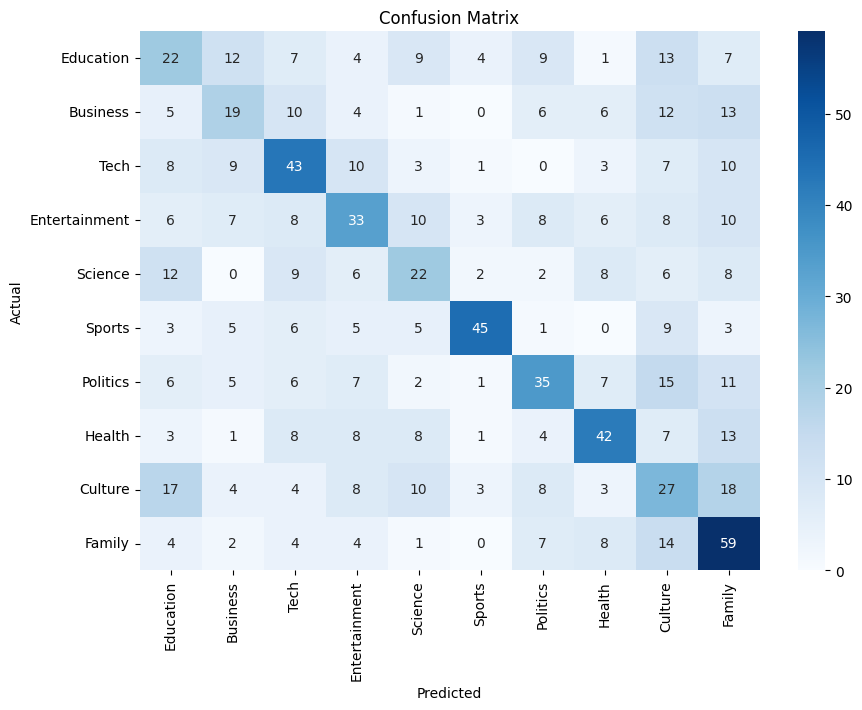

In [19]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

In [20]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/yahoo-answers/results/predictions/yahoo-llama-3.2-3b-fewshot-tfidf-2.0k-samples-1-shots-fixed.json")

Results saved to: '/home/v25/ippa6201/cicle-evaluation/yahoo-answers/results/predictions/yahoo-llama-3.2-3b-fewshot-tfidf-2.0k-samples-1-shots-fixed.json'


In [21]:
save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="/home/v25/ippa6201/cicle-evaluation/yahoo-answers/results/lengths/yahoo-llama-3.2-3b-fewshot-tfidf-2.0k-samples-1-shots-fixed.json")

Prompt length statistics saved to: '/home/v25/ippa6201/cicle-evaluation/yahoo-answers/results/lengths/yahoo-llama-3.2-3b-fewshot-tfidf-2.0k-samples-1-shots-fixed.json'
